      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1138            6.3             0.510         0.13             2.3      0.076   
1139            6.8             0.620         0.08             1.9      0.068   
1140            6.2             0.600         0.08             2.0      0.090   
1141            5.9             0.550         0.10             2.2      0.062   
1142            5.9             0.645         0.12             2.0      0.075   

      free sulfur dioxide  

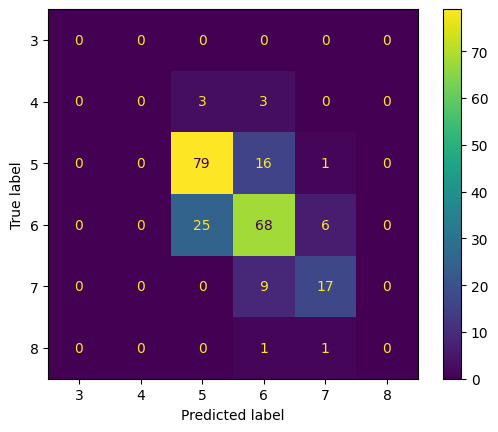

In [5]:
#model1_RandomForestClassifier
#1.Training

#1.a) Load Data
import pandas as pd

file = pd.read_csv("/content/WineQT.csv")

print(file)
print(file.head())
print(file.shape)

x = file.drop(["quality","Id"], axis=1)
y = file["quality"]

#1.b) Data Preprocessing
print(file.isnull().sum())

print(file["quality"].value_counts())

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#1.c) Load Model Random Forest
from sklearn.ensemble import RandomForestClassifier

model1 = RandomForestClassifier()

#1.d Fit Data into model
model1 = model1.fit(x_train, y_train)

print(model1.classes_)
print("Total Classes =", len(model1.classes_))

#2.Testing
op = model1.predict(x_test)

print(op)

from sklearn.metrics import accuracy_score

acc=(accuracy_score(y_test, op))
print("accuracy=", acc*100)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, op, labels=model1.classes_)
print(cm)

from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model1.classes_)
disp.plot()